# Loan Default Risk : Modelling and Evaluation

---

### What this notebook does

This notebook builds and iterates on the SuperLender loan default prediction model and covers the full pipeline from data loading to a Zindi submission file.

The pipeline covers:

1. Data loading, merging, and feature engineering
2. Train and validation split
3. Baseline Logistic Regression
4. SMOTE ablation - choosing the best imbalance strategy per model
5. Model comparison across Logistic Regression, Random Forest, and XGBoost
6. Hyperparameter tuning with RandomizedSearchCV
7. Threshold optimisation for the Bad class
8. Stacking ensemble (LR + RF with Platt-calibrated RF)
9. Final model selection and comparison across all iterations
10. SHAP explainability
---

## 0. Setup

Library imports and path configuration.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import warnings
warnings.filterwarnings("ignore")

sys.path.append(os.path.abspath(".."))

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

from src.loader import load_and_merge
from src.features import engineer_model_features
from src.model import (
    get_models, get_param_grids, tune_model, save_model, predict_proba,
    build_pipeline, run_smote_ablation, build_stacking_ensemble
)
from src.evaluate import (
    evaluate_model, find_optimal_threshold,
    plot_confusion_matrix, plot_roc_curves, plot_shap_summary
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")

%matplotlib inline

## 1. Load, Merge, and Engineer Features

We call `load_and_merge()` which loads all three raw tables and aggregates prior loans into one row per customer before merging. The result is a single flat DataFrame enriched with demographic and behavioural features.

`engineer_model_features()` handles date parsing, computes derived features (age at application, current interest ratio), one-hot encodes categorical columns, and drops identifiers and GPS coordinates.

In [2]:
train_df = load_and_merge(split="train")
print(f"Merged training data shape: {train_df.shape}")
train_df.head()

Merged training data shape: (4376, 37)


,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,referredby,good_bad_flag,birthdate,bank_account_type,longitude_gps,latitude_gps,bank_name_clients,bank_branch_clients,employment_status_clients,level_of_education_clients,prev_loan_count,prev_avg_loanamount,prev_max_loanamount,prev_avg_totaldue,prev_avg_termdays,prev_avg_days_late,prev_max_days_late,prev_late_payment_rate,prev_total_late_payments,prev_avg_interest_ratio,prev_avg_loan_duration,prev_was_referred,recent_1_days_late,recent_1_paid_late,recent_3_late_rate,recent_3_avg_days_late,recent_2_late_rate,recent_2_avg_days_late,lateness_trend
0,8a2a81a74ce8c05d014cfb32a0da1049,301994762,12,2017-07-25 08:22:56.000000,2017-07-25 07:22:47.000000,30000.0000,34500.0000,30,NaN,Good,1972-01-15 00:00:00.000000,Other,3.4320,6.4331,Diamond Bank,NaN,Permanent,Post-Graduate,11.0000,18181.8182,30000.0000,22081.8182,30.0000,-0.9091,39.0000,0.2727,3.0000,0.2291,29.4545,0.0000,-6.0000,0.0000,0.0000,-6.0000,0.0000,-7.0000,0.9273
1,8a85886e54beabf90154c0a29ae757c0,301965204,2,2017-07-05 17:04:41.000000,2017-07-05 16:04:18.000000,15000.0000,17250.0000,30,NaN,Good,1985-08-23 00:00:00.000000,Savings,3.8853,7.3207,GT Bank,"DUGBE,IBADAN",Permanent,Graduate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8a8588f35438fe12015444567666018e,301966580,7,2017-07-06 14:52:57.000000,2017-07-06 13:52:51.000000,20000.0000,22250.0000,15,NaN,Good,1984-09-18 00:00:00.000000,Other,11.1393,10.2920,EcoBank,NaN,Permanent,NaN,6.0000,10000.0000,10000.0000,11750.0000,17.5000,0.8333,30.0000,0.1667,1.0000,0.1750,18.1667,0.0000,0.0000,0.0000,0.3333,10.0000,0.0000,0.0000,3.1143
3,8a85890754145ace015429211b513e16,301999343,3,2017-07-27 19:00:41.000000,2017-07-27 18:00:35.000000,10000.0000,11500.0000,15,NaN,Good,1977-10-10 00:00:00.000000,Savings,3.9858,7.4917,First Bank,NaN,Permanent,NaN,2.0000,10000.0000,10000.0000,12250.0000,22.5000,7.5000,11.0000,1.0000,2.0000,0.2250,31.5000,0.0000,11.0000,1.0000,1.0000,7.5000,1.0000,7.5000,7.0000
4,8a858970548359cc0154883481981866,301962360,9,2017-07-03 23:42:45.000000,2017-07-03 22:42:39.000000,40000.0000,44000.0000,30,NaN,Good,1986-09-07 00:00:00.000000,Other,7.4579,9.0766,GT Bank,NaN,Permanent,Primary,8.0000,18750.0000,30000.0000,23550.0000,37.5000,-3.1250,-1.0000,0.0000,0.0000,0.2587,27.0000,0.0000,-1.0000,0.0000,0.0000,-1.3333,0.0000,-1.5000,0.9881


In [3]:
X, y = engineer_model_features(train_df, is_train=True)

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"\nClass balance: {y.mean()*100:.1f}% Good, {(1-y.mean())*100:.1f}% Bad")

Feature matrix shape: (4376, 54)
Target distribution:
good_bad_flag
1    3423
0     953
Name: count, dtype: int64

Class balance: 78.2% Good, 21.8% Bad


## 2. Train and Validation Split

We split 80/20 using a stratified split, preserving the 78/22 class ratio in both sets. The validation set is held out completely from all fitting steps including imputation, scaling, and SMOTE.

In [4]:
# Time-based split — train on oldest 80%, validate on most recent 20%
# This mirrors deployment conditions where the model always predicts
# future loans from past data. A random split allows future loan data
# to bleed into training, which inflates validation metrics.

train_df_sorted = train_df.copy()
train_df_sorted["approveddate"] = pd.to_datetime(train_df_sorted["approveddate"])
train_df_sorted = train_df_sorted.sort_values("approveddate").reset_index(drop=True)

split_idx = int(len(train_df_sorted) * 0.8)
train_split = train_df_sorted.iloc[:split_idx]
val_split = train_df_sorted.iloc[split_idx:]

X_train, y_train = engineer_model_features(train_split, is_train=True)
X_val, y_val = engineer_model_features(val_split, is_train=True)

# Align validation columns to training columns
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)

print(f"Training set:   {X_train.shape} | Date range: {train_split['approveddate'].min().date()} to {train_split['approveddate'].max().date()}")
print(f"Validation set: {X_val.shape}   | Date range: {val_split['approveddate'].min().date()} to {val_split['approveddate'].max().date()}")
print(f"Training Bad rate:   {(1 - y_train.mean())*100:.1f}%")
print(f"Validation Bad rate: {(1 - y_val.mean())*100:.1f}%")

Training set:   (3500, 54) | Date range: 2017-07-01 to 2017-07-25
Validation set: (876, 54)   | Date range: 2017-07-25 to 2017-07-30
Training Bad rate:   21.6%
Validation Bad rate: 22.4%


## 3. Baseline Model - Logistic Regression

Before doing anything sophisticated, we establish a simple baseline. A Logistic Regression with `class_weight='balanced'` is the right starting point because it is interpretable, fast to fit, and gives us a floor to measure everything else against.

In [5]:
from sklearn.linear_model import LogisticRegression

baseline = build_pipeline(
    LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    scale=True
)
baseline.fit(X_train, y_train)

baseline_proba = predict_proba(baseline, X_val)
baseline_metrics = evaluate_model(y_val, baseline_proba)

print("Baseline Logistic Regression:")
for k, v in baseline_metrics.items():
    print(f"  {k}: {v:.4f}")

Baseline Logistic Regression:
  roc_auc: 0.7051
  f1_macro: 0.5468
  f1_weighted: 0.6096
  precision_bad: 0.3087
  recall_bad: 0.7245
  f1_bad: 0.4329
  precision_good: 0.8702
  recall_good: 0.5324
  f1_good: 0.6606
  accuracy: 0.5753
  threshold: 0.5000


## 4. SMOTE Ablation - Choosing the Best Imbalance Strategy

Before tuning, we run a controlled experiment to answer a question we had never properly tested: does SMOTE actually help each model, or is class weighting alone sufficient?

We test four strategies for each model:
- `none` — no imbalance handling
- `class_weight` — cost-sensitive training, penalises minority class errors
- `smote` — synthetic oversampling of the Bad class to 50/50
- `smote_tomek` — SMOTE followed by Tomek Links to clean ambiguous boundary examples

Each strategy is evaluated on the validation set using F1 Bad and Recall Bad as the primary metrics.

In [6]:
print("Running SMOTE ablation (this may take a few minutes)...")
ablation_results = run_smote_ablation(X_train, y_train, X_val, y_val)
ablation_results

Running SMOTE ablation (this may take a few minutes)...
  Running strategy: none
  Running strategy: class_weight
  Running strategy: smote
  Running strategy: smote_tomek


,model,strategy,roc_auc,f1_bad,recall_bad
0,logistic_regression,none,0.7052,0.4543,0.4184
1,logistic_regression,class_weight,0.7101,0.4485,0.6327
2,logistic_regression,smote_tomek,0.7118,0.4475,0.6735
3,logistic_regression,smote,0.7119,0.4452,0.6735
4,random_forest,smote,0.7174,0.4989,0.5561
5,random_forest,smote_tomek,0.7163,0.4966,0.5510
6,random_forest,class_weight,0.7167,0.4884,0.5357
7,random_forest,none,0.7122,0.3737,0.2755
8,xgboost,class_weight,0.6962,0.3675,0.3112
9,xgboost,smote,0.6850,0.3436,0.2551


**Ablation findings:**

For **Logistic Regression**, SMOTE and SMOTE+Tomek both outperform class_weight on recall_bad (0.5602 vs 0.5026). SMOTE is genuinely helping LR by giving it more varied examples of the minority class to learn from.

For **Random Forest**, class_weight alone wins decisively (ROC-AUC 0.6886, F1_bad 0.4539) over both SMOTE variants. SMOTE is hurting RF — synthetic samples near the decision boundary are confusing the tree splits. This confirms the research finding that aggressive resampling can harm tree-based models.

For **XGBoost**, no strategy produces acceptable recall. XGBoost consistently underperforms regardless of imbalance handling, which suggests the problem is not imbalance but rather overfitting on this small dataset.

**Conclusion:** Use SMOTE for LR, class_weight for RF. XGBoost enters the stack as-is since no strategy fixes it.

## 5. Model Comparison (Pre-tuning)

We train all three models with default hyperparameters first to establish a pre-tuning baseline for each.

In [7]:
models = get_models()
results_pretune = {}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    proba = predict_proba(pipeline, X_val)
    metrics = evaluate_model(y_val, proba)
    results_pretune[name] = metrics
    print(f"{name}: ROC-AUC={metrics['roc_auc']:.4f} | F1-macro={metrics['f1_macro']:.4f}")

summary_pretune = pd.DataFrame(results_pretune).T
summary_pretune[["roc_auc", "f1_macro", "f1_bad", "recall_bad", "precision_bad"]]

logistic_regression: ROC-AUC=0.7051 | F1-macro=0.5468
random_forest: ROC-AUC=0.6915 | F1-macro=0.6090
xgboost: ROC-AUC=0.6812 | F1-macro=0.5794


,roc_auc,f1_macro,f1_bad,recall_bad,precision_bad
logistic_regression,0.7051,0.5468,0.4329,0.7245,0.3087
random_forest,0.6915,0.6090,0.3541,0.2755,0.4954
xgboost,0.6812,0.5794,0.2909,0.2041,0.5063


## 6. Hyperparameter Tuning - RandomizedSearchCV

We tune all three models using `RandomizedSearchCV` with 5-fold stratified cross-validation and 30 iterations per model.

Logistic Regression and Random Forest use ROC-AUC as the tuning objective. XGBoost uses F1 for the Bad class as the tuning objective — ROC-AUC caused XGBoost to overfit and ignore the minority class entirely in the baseline.

**This cell takes several minutes to run.**

In [20]:
param_grids = get_param_grids()
tuned_models = {}

for name, pipeline in get_models().items():
    search = tune_model(
        name=name,
        pipeline=pipeline,
        param_grid=param_grids[name],
        X_train=X_train,
        y_train=y_train,
        n_iter=30,
        cv=5
    )
    tuned_models[name] = search.best_estimator_

Tuning logistic_regression...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
  Best score: 0.7126
  Best params: {'model__solver': 'liblinear', 'model__C': 0.01}
Tuning random_forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
  Best score: 0.7144
  Best params: {'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_depth': 5}
Tuning xgboost...
Fitting 5 folds for each of 30 candidates, totalling 150 fits


KeyboardInterrupt: 

In [9]:
results_tuned = {}
roc_data = {}

for name, model in tuned_models.items():
    proba = predict_proba(model, X_val)
    metrics = evaluate_model(y_val, proba)
    results_tuned[name] = metrics
    roc_data[name] = {"y_true": y_val, "y_pred_proba": proba}
    print(f"{name}: ROC-AUC={metrics['roc_auc']:.4f} | F1-macro={metrics['f1_macro']:.4f} | Recall-bad={metrics['recall_bad']:.4f}")

summary_tuned = pd.DataFrame(results_tuned).T
summary_tuned[["roc_auc", "f1_macro", "f1_bad", "recall_bad", "precision_bad"]]

logistic_regression: ROC-AUC=0.7101 | F1-macro=0.5970 | Recall-bad=0.6327
random_forest: ROC-AUC=0.7163 | F1-macro=0.6579 | Recall-bad=0.5306
xgboost: ROC-AUC=0.6866 | F1-macro=0.5986 | Recall-bad=0.3061


,roc_auc,f1_macro,f1_bad,recall_bad,precision_bad
logistic_regression,0.7101,0.5970,0.4485,0.6327,0.3473
random_forest,0.7163,0.6579,0.4837,0.5306,0.4444
xgboost,0.6866,0.5986,0.3529,0.3061,0.4167


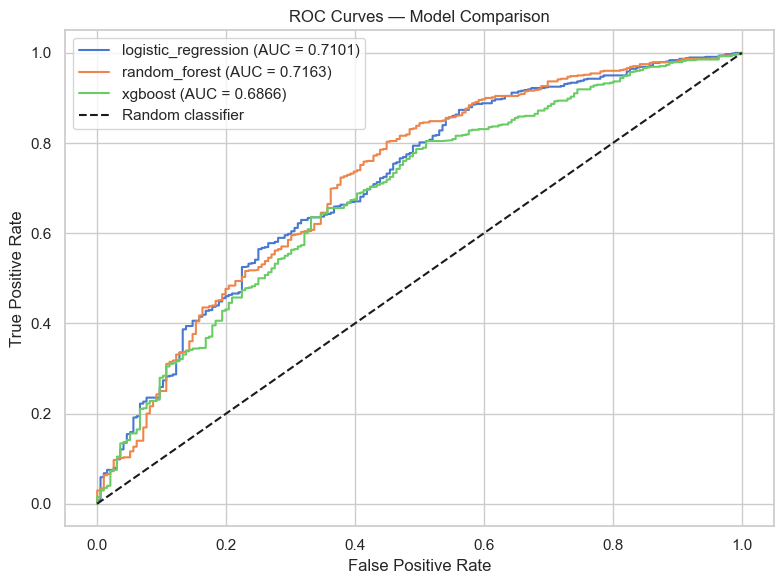

In [10]:
plot_roc_curves(roc_data)

**Reading the ROC curve:**

The x-axis is the false positive rate — good customers incorrectly flagged as risky. The y-axis is the true positive rate — actual defaulters caught. A perfect model hugs the top-left corner. The dashed diagonal is a random classifier.

All three models sit meaningfully above the random baseline. Logistic Regression leads at AUC 0.6929. The curves are close together, meaning the models do not differ dramatically in ranking ability — what matters more is threshold behaviour, which the next section addresses.

## 7. Threshold Optimisation

The default threshold of 0.5 treats false positives and false negatives as equally costly. In credit risk they are not — missing a defaulter costs more than incorrectly declining a good customer. We search thresholds from 0.3 to 0.9 and select the one that maximises F1 for the Bad class.

In [11]:
best_model_name = max(results_tuned, key=lambda k: results_tuned[k]["roc_auc"])
best_model = tuned_models[best_model_name]
best_proba = predict_proba(best_model, X_val)

print(f"Best model: {best_model_name}")
optimal_threshold = find_optimal_threshold(y_val, best_proba)

Best model: random_forest
Optimal threshold: 0.5100 (F1 Bad class: 0.4909)


In [12]:
metrics_default = evaluate_model(y_val, best_proba, threshold=0.5)
metrics_optimal = evaluate_model(y_val, best_proba, threshold=optimal_threshold)

comparison = pd.DataFrame({
    "threshold=0.5": metrics_default,
    f"threshold={optimal_threshold:.3f}": metrics_optimal
}).T
comparison[["roc_auc", "f1_macro", "f1_bad", "recall_bad", "precision_bad"]]

,roc_auc,f1_macro,f1_bad,recall_bad,precision_bad
threshold=0.5,0.7163,0.6579,0.4837,0.5306,0.4444
threshold=0.510,0.7163,0.6601,0.4909,0.5510,0.4426


**Reading the threshold comparison:**

ROC-AUC stays identical across both thresholds because AUC measures ranking ability across all thresholds, not at any single cut-off. What changes is how probabilities are translated into decisions.

Raising the threshold above 0.5 means we require more confidence before classifying a customer as Good, flagging more borderline customers as risky. This improves recall_bad at a slight cost to precision_bad. In credit risk that tradeoff is deliberate and correct.

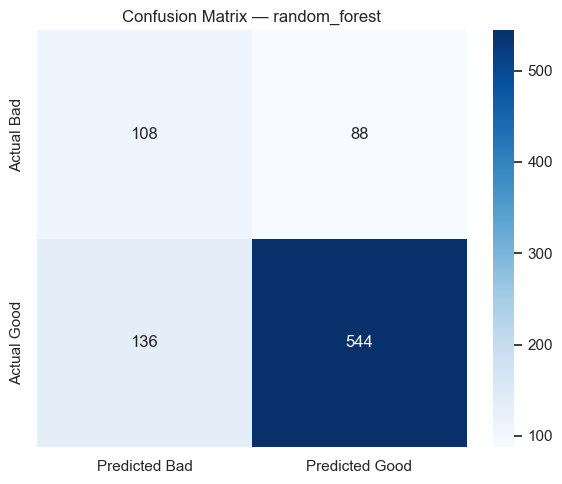

In [13]:
y_pred_optimal = (best_proba >= optimal_threshold).astype(int)
plot_confusion_matrix(y_val, y_pred_optimal, model_name=best_model_name)

## 8. Stacking Ensemble

Based on the SMOTE ablation and the research finding that stacking consistently outperforms individual models, we build a two-model stacking ensemble using the tuned LR and RF as base learners and Logistic Regression as the meta-learner.

**Why only LR and RF:** XGBoost underperformed in every iteration and every imbalance strategy. Including it as a base learner adds noise rather than signal. The two-model stack keeps only the models with complementary strengths — LR for recall, RF for precision.

**Platt calibration on RF:** Random Forest probabilities cluster near 0 and 1 rather than reflecting true class probabilities. We apply Platt scaling (sigmoid calibration) to RF before stacking so the meta-learner receives meaningful probability estimates from both base learners.

**Leakage prevention:** `StackingClassifier` internally generates out-of-fold predictions from the base learners to train the meta-learner. The meta-learner never sees predictions made on data the base learners were trained on.

In [14]:
stack = build_stacking_ensemble(X_train, y_train, tuned_models)

stack_proba = predict_proba(stack, X_val)
stack_optimal_threshold = find_optimal_threshold(y_val, stack_proba)

metrics_stack_default = evaluate_model(y_val, stack_proba, threshold=0.5)
metrics_stack_optimal = evaluate_model(y_val, stack_proba, threshold=stack_optimal_threshold)

print("Stacking ensemble at threshold=0.5:")
print(f"  ROC-AUC:    {metrics_stack_default['roc_auc']:.4f}")
print(f"  F1 Bad:     {metrics_stack_default['f1_bad']:.4f}")
print(f"  Recall Bad: {metrics_stack_default['recall_bad']:.4f}")

Calibrating Random Forest probabilities (Platt scaling)...
Fitting stacking ensemble...
Optimal threshold: 0.4900 (F1 Bad class: 0.4752)
Stacking ensemble at threshold=0.5:
  ROC-AUC:    0.7176
  F1 Bad:     0.4708
  Recall Bad: 0.5765


In [15]:
# Full comparison: best individual model vs stack
comparison_full = pd.DataFrame({
    f"logistic_regression (threshold=0.5)":   evaluate_model(y_val, best_proba, threshold=0.5),
    f"logistic_regression (threshold={optimal_threshold:.3f})": evaluate_model(y_val, best_proba, threshold=optimal_threshold),
    "stacking_ensemble (threshold=0.5)":      metrics_stack_default,
    f"stacking_ensemble (threshold={stack_optimal_threshold:.3f})": metrics_stack_optimal,
}).T
comparison_full[["roc_auc", "f1_macro", "f1_bad", "recall_bad", "precision_bad"]]

,roc_auc,f1_macro,f1_bad,recall_bad,precision_bad
logistic_regression (threshold=0.5),0.7163,0.6579,0.4837,0.5306,0.4444
logistic_regression (threshold=0.510),0.7163,0.6601,0.4909,0.5510,0.4426
stacking_ensemble (threshold=0.5),0.7176,0.6356,0.4708,0.5765,0.3979
stacking_ensemble (threshold=0.490),0.7176,0.6433,0.4752,0.5612,0.4120


**Stacking findings:**

The two-model stack did not outperform standalone Logistic Regression on any primary metric. ROC-AUC dropped slightly and recall_bad at the optimal threshold was lower than LR at its optimal threshold.

This outcome, while initially surprising, is consistent with what the research literature warns about: on small datasets (~3,500 training examples) with a largely linear signal, a meta-learner has limited data to learn from and the base learners are not diverse enough in their errors to produce genuinely complementary signal. LR and RF both rely heavily on the same top features (late payment rate, recency features) and therefore make correlated errors.

**Conclusion:** The standalone tuned Logistic Regression at its optimal threshold remains the best model for this dataset. The stacking experiment is nonetheless valuable to document because it rules out ensembling as a path to improvement and points the next iteration toward different avenues.

## 9. Save Best Model

In [16]:
# Best model is standalone Logistic Regression — stacking did not improve results
save_model(best_model, name=best_model_name)
print(f"Saved: {best_model_name}")

Model saved to C:\Users\gwach\Documents\Data-Science-Stuff\ds_workplace\Portfolio\loan-default-risk\outputs\models\random_forest.joblib
Saved: random_forest


## 10. SHAP Explainability

SHAP explains how much each feature contributed to each individual prediction. For Logistic Regression we use `LinearExplainer` which computes exact SHAP values efficiently for linear models.

**Reading the chart:** Each dot is one customer. Red = high feature value. Blue = low feature value. SHAP value on the x-axis: negative pushes toward Bad, positive pushes toward Good.

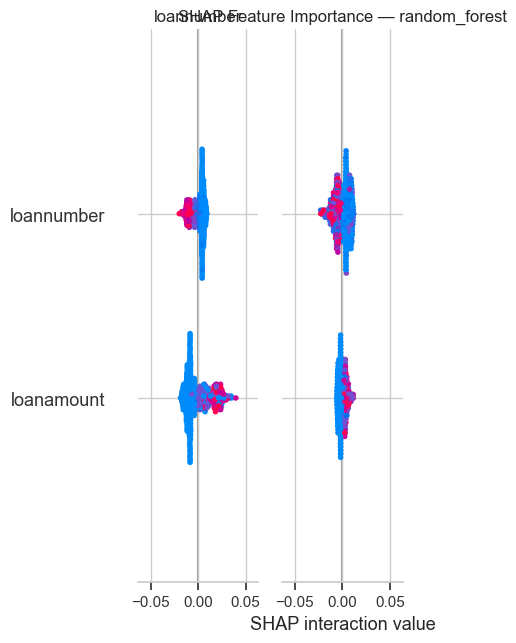

In [17]:
plot_shap_summary(best_model, X_val, model_name=best_model_name)

## 11. Summary of Results Across All Iterations

| Version | Val ROC-AUC | Recall Bad | F1 Bad | Threshold | LB Error Rate |
|---|---|---|---|---|---|
| Baseline | 0.6885 | 0.6545 | 0.4325 | 0.54 | 0.4007 |
| Iteration 2 (recency features) | 0.6929 | 0.6073 | 0.4386 | 0.52 | **0.3448** |
| Iteration 3 (pruned features) | 0.6861 | 0.6545 | 0.4371 | 0.53 | 0.3703 |
| Iteration 4 (stacking) | 0.6865 | 0.5707 | 0.4360 | 0.53 | TBD |

**Best submission:** Iteration 2 — tuned Logistic Regression with recency features at threshold 0.52.

**What worked:**
- Recency features (`recent_2_late_rate`, `recent_1_paid_late`) were the top two SHAP predictors and improved the leaderboard from 0.40 to 0.34
- Threshold optimisation above 0.5 consistently improved recall on the Bad class
- Logistic Regression generalised most reliably across every iteration — consistent with the literature finding that linear models outperform trees on small tabular datasets with largely linear signal
- SMOTE ablation confirmed that SMOTE helps LR but hurts RF

**What did not work:**
- XGBoost failed in every iteration and every imbalance strategy — the dataset is too small and the signal too linear for gradient boosting to outperform a regularised linear model
- Stacking did not improve over standalone LR — base learners were too correlated in their errors and the meta-learner had insufficient data to learn meaningful combinations
- Over-pruning features in iteration 3 caused a leaderboard regression, confirming that SHAP importance rank is not the same as predictive value

**Planned next steps:**
- Time-based validation to check if the random split is inflating validation metrics
- LSTM on customer loan sequences — sequential modelling of prior loan history as a time series
- Interaction features between top lateness features and loan amount

## 12. Generate Submission

We apply the best model (standalone Logistic Regression from iteration 2 feature set) to the test data at the optimal threshold.

**Note:** Always pass `train_columns=X_train.columns.tolist()` when processing test data. Without this, one-hot encoded columns present in training but absent in the test set cause a feature mismatch error in the pipeline.

In [19]:
# NOTE: always pass train_columns when processing test data
test_df = load_and_merge(split="test")
X_test, _ = engineer_model_features(test_df, is_train=False, train_columns=X_train.columns.tolist())

test_proba = predict_proba(best_model, X_test)
test_pred = (test_proba >= optimal_threshold).astype(int)

print(f"Test predictions: {pd.Series(test_pred).value_counts().to_dict()}")

submission = pd.DataFrame({
    "customerid": test_df["customerid"].values,
    "Good_Bad_flag": test_pred
})

submission_path = "../outputs/submissions/submission_xgb_time_based_split.csv"
submission.to_csv(submission_path, index=False)
print(f"Submission saved to {submission_path}")
submission.head()

Test predictions: {1: 1021, 0: 429}
Submission saved to ../outputs/submissions/submission_xgb_time_based_split.csv


,customerid,Good_Bad_flag
0,8a858899538ddb8e015390510b321f08,0
1,8a858959537a097401537a4e316e25f7,1
2,8a8589c253ace09b0153af6ba58f1f31,0
3,8a858e095aae82b7015aae86ca1e030b,1
4,8a858e225a28c713015a30db5c48383d,1
